# Task 3 

In [68]:
#!pip install -q langchain langchain-google-genai google-generativeai datasets pandas matplotlib pydantic tqdm

import os, json, random, time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

if not os.getenv("GOOGLE_API_KEY"):
    raise RuntimeError("Set GOOGLE_API_KEY before running model-backed cells.")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

## 1.1 

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

MODEL_PRIORITY = ["gemma-3-27b-it", "gemma-3-12b-it", "gemini-3.1-flash-lite"]

_active_model_name = None
_llm = None

def get_llm(temperature=0.3):
    global _active_model_name, _llm
    if _llm is not None:
        return _llm
    last_err = None
    for name in MODEL_PRIORITY:
        try:
            candidate = ChatGoogleGenerativeAI(model=name, temperature=temperature)
            candidate.invoke("ping")  # smoke test
            _active_model_name = name
            _llm = candidate
            print(f"Using model: {name}")
            return _llm
        except Exception as e:
            print(f"Model {name} failed ({e}); trying next...")
            last_err = e
    raise RuntimeError(f"All models failed: {last_err}")

llm = get_llm()

Model gemma-3-27b-it failed (Error calling model 'gemma-3-27b-it' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemma-3-27b-it is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}); trying next...
Model gemma-3-12b-it failed (Error calling model 'gemma-3-12b-it' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemma-3-12b-it is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}); trying next...


In [ ]:
resp = llm.invoke("In one sentence, what is photosynthesis?")
print(resp.content)

[{'type': 'text', 'text': 'Photosynthesis is the process by which green plants and certain other organisms transform light energy into chemical energy, using sunlight to convert water and carbon dioxide into oxygen and energy-rich carbohydrates like glucose.', 'extras': {'signature': 'EjQKMgERTTIPZPu5C3qTyjPg+tvhnX8HGn8G1aon9aHxsPZ86KIeXjuYc2obvreuG1V7wB0T'}}]


### Load OpenBookQA



In [8]:
from datasets import load_dataset

obqa = load_dataset("allenai/openbookqa", "main")
print(obqa)
print(obqa["train"][0])

obqa_df = obqa["train"].to_pandas()
print(obqa_df.shape)
obqa_df.head()

README.md: 0.00B [00:00, ?B/s]

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\datasets--allenai--openbookqa. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for th

train-00000-of-00001.parquet:   0%|          | 0.00/496k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/58.2k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/4957 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 4957
    })
    validation: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 500
    })
})
{'id': '7-980', 'question_stem': 'The sun is responsible for', 'choices': {'text': ['puppies learning new tricks', 'children growing up and getting old', 'flowers wilting in a vase', 'plants sprouting, blooming and wilting'], 'label': ['A', 'B', 'C', 'D']}, 'answerKey': 'D'}
(4957, 4)


,id,question_stem,choices,answerKey
0,7-980,The sun is responsible for,"{'text': ['puppies learning new tricks', 'chil...",D
1,7-584,When standing miles away from Mount Rushmore,"{'text': ['the mountains seem very close', 'th...",D
2,7-870,When food is reduced in the stomach,"{'text': ['the mind needs time to digest', 'ta...",C
3,7-321,Stars are,"{'text': ['warm lights that float', 'made out ...",C
4,9-732,You can make a telescope with a,"{'text': ['straw', 'Glass', 'Candle', 'mailing...",D


## 1.2 Prompt Templates

In [9]:
from langchain_core.prompts import PromptTemplate

qa_prompt = PromptTemplate(
    input_variables=["question", "choices"],
    template=(
        "Question: {question}\n"
        "Choices:\n{choices}\n\n"
        "Answer the question. Give only the best choice and a short justification."
    ),
)

def format_choices(example):
    labels = example["choices"]["label"]
    texts = example["choices"]["text"]
    return "\n".join(f"{l}. {t}" for l, t in zip(labels, texts))

sample3 = obqa_df.sample(3, random_state=RANDOM_SEED)
for _, row in sample3.iterrows():
    prompt = qa_prompt.format(question=row["question_stem"], choices=format_choices(row))
    out = llm.invoke(prompt)
    print(prompt)
    print("--->", out.content)
    print("=" * 60)

Question: Which is likeliest to metamorphose?
Choices:
A. a live insect
B. a human
C. a plant
D. a dead butterfly

Answer the question. Give only the best choice and a short justification.
---> [{'type': 'text', 'text': 'Answer: A. a live insect\n\nJustification: Metamorphosis is a biological process specifically defined by the developmental transformation of an insect from an immature form (like a larva or nymph) into an adult.', 'extras': {'signature': 'EjQKMgERTTIPyRECOqIWrT9exk+NsEV6b85cqJh4lYhacArDkmunr+GF0fDN30IzasCxeQq1'}}]
Question: Which animal is most likely to eat another living animal?
Choices:
A. deer
B. elephant
C. worm
D. lion

Answer the question. Give only the best choice and a short justification.
---> [{'type': 'text', 'text': 'Answer: D. lion\n\nJustification: Lions are obligate carnivores, meaning their diet consists almost exclusively of meat from other animals, whereas the other options are primarily herbivores or detritivores.', 'extras': {'signature': 'EjQKMgER

## 1.3 Structured Output Parsing

In [ ]:
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.exceptions import OutputParserException

class QAResponse(BaseModel):
    answer: str = Field(description="The selected choice, e.g. 'A' or the choice text")
    reasoning: str = Field(description="Free-text reasoning for the answer")
    confidence: float = Field(description="Confidence from 0 to 1")

qa_parser = PydanticOutputParser(pydantic_object=QAResponse)

structured_prompt = PromptTemplate(
    input_variables=["question", "choices"],
    partial_variables={"format_instructions": qa_parser.get_format_instructions()},
    template=(
        "Question: {question}\nChoices:\n{choices}\n\n"
        "{format_instructions}"
    ),
)

def _get_text(content):
   
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, str):
                parts.append(block)
            elif isinstance(block, dict) and "text" in block:
                parts.append(block["text"])
        return "".join(parts)
    return str(content)

def ask_structured(question, choices, parser=qa_parser, prompt=structured_prompt, retries=1):
    raw = None
    text = None
    for attempt in range(retries + 1):
        raw = llm.invoke(prompt.format(question=question, choices=choices))
        text = _get_text(raw.content)
        try:
            return parser.parse(text), text
        except OutputParserException as e:
            print(f"Parse failure on attempt {attempt}: {e}")
  
    from langchain.output_parsers import OutputFixingParser
    fixer = OutputFixingParser.from_llm(parser=parser, llm=llm)
    return fixer.parse(text), text

for _, row in sample3.iterrows():
    result, raw = ask_structured(row["question_stem"], format_choices(row))
    print(result)
    print("-" * 40)

answer='A' reasoning="Metamorphosis is a biological process by which an animal physically develops after birth or hatching, involving a conspicuous and relatively abrupt change in the animal's body structure through cell growth and differentiation. This is a characteristic life cycle stage for many insects (e.g., butterflies, beetles). Humans do not undergo metamorphosis, plants undergo developmental changes but not metamorphosis in the zoological sense, and a dead insect cannot undergo biological processes." confidence=1.0
----------------------------------------
answer='D' reasoning='A lion is an obligate carnivore, meaning its diet consists primarily of meat from other animals. Deer and elephants are herbivores, and while some worms are predatory, the lion is the most iconic and definitive predator among the choices provided.' confidence=1.0
----------------------------------------
answer='D' reasoning='A multifaceted object has many flat surfaces (facets). Among the choices, a ball

## 1.4 Dataset Enrichment

In [13]:
SUBJECT_AREAS = ["physics", "biology", "chemistry", "earth_science", "astronomy", "other"]

DIFFICULTY_RUBRIC = """
1 = single fact recall
2 = recall + trivial application
3 = requires combining two related facts
4 = requires multi-step reasoning over 2-3 concepts
5 = requires combining multiple concepts + inference beyond the text
"""

class Annotation(BaseModel):
    subject_area: str = Field(description=f"One of {SUBJECT_AREAS}")
    difficulty: int = Field(description="Integer 1-5 per the rubric")
    reasoning: str = Field(description="Brief justification")

annotation_parser = PydanticOutputParser(pydantic_object=Annotation)

annotation_prompt = PromptTemplate(
    input_variables=["question", "choices"],
    partial_variables={
        "format_instructions": annotation_parser.get_format_instructions(),
        "subjects": ", ".join(SUBJECT_AREAS),
        "rubric": DIFFICULTY_RUBRIC,
    },
    template=(
        "You are annotating a science QA dataset.\n"
        "Allowed subject areas: {subjects}\n"
        "Difficulty rubric:\n{rubric}\n\n"
        "Question: {question}\nChoices:\n{choices}\n\n{format_instructions}"
    ),
)

def annotate(row):
    result, _ = ask_structured(
        row["question_stem"], format_choices(row),
        parser=annotation_parser, prompt=annotation_prompt,
    )
    return result

working_100 = obqa_df.sample(40, random_state=RANDOM_SEED).reset_index(drop=True)

records = []
for _, row in tqdm(working_100.iterrows(), total=len(working_100)):
    ann = annotate(row)
    records.append({
        "id": row["id"],
        "question_stem": row["question_stem"],
        "choices": format_choices(row),
        "answerKey": row["answerKey"],
        "subject_area": ann.subject_area,
        "difficulty": ann.difficulty,
        "reasoning": ann.reasoning,
    })

enriched_df = pd.DataFrame(records)
enriched_df.to_csv("enriched_questions.csv", index=False)
enriched_df.head()

  0%|          | 0/40 [00:00<?, ?it/s]

,id,question_stem,choices,answerKey,subject_area,difficulty,reasoning
0,12-878,Which is likeliest to metamorphose?,A. a live insect\nB. a human\nC. a plant\nD. a...,A,biology,2,The question requires understanding the biolog...
1,11-287,Which animal is most likely to eat another liv...,A. deer\nB. elephant\nC. worm\nD. lion,D,biology,1,The question requires simple factual recall re...
2,13-886,"If a see through thing is multifaceted, it is ...",A. a ball\nB. an apple\nC. a silver globe\nD. ...,D,other,2,The question requires understanding the defini...
3,11-497,Which two objects would electricity best flow ...,A. a tin can and a plastic fork\nB. a steel be...,B,physics,2,The question requires identifying which materi...
4,9-173,When a wolf is buried what will happen to othe...,A. small change\nB. learn to fly\nC. less of t...,C,biology,2,The question requires understanding basic popu...


In [ ]:

enriched_df.sample(10, random_state=1)[["question_stem", "subject_area", "difficulty", "reasoning"]]

,question_stem,subject_area,difficulty,reasoning
2,"If a see through thing is multifaceted, it is ...",other,2,The question requires understanding the defini...
31,Squirrels can often be seen storing acorns dur...,biology,1,This is a basic fact-recall question regarding...
3,Which two objects would electricity best flow ...,physics,2,The question requires identifying which materi...
21,Corn would likely provide nutrients to,biology,1,The question tests the basic biological concep...
27,"In the natural world, camouflage is used by an...",biology,1,The question requires simple recall of the bio...
29,If the Earth revolved around another planet in...,astronomy,4,The question requires understanding the mechan...
22,Dogs,biology,1,The question tests basic knowledge of mammalia...
39,"If a wolf is unable to catch prey reliably, th...",biology,2,The question requires understanding the biolog...
19,What anchors plants into the soil are called,biology,1,The question asks for the definition of a basi...
26,Which acts as an insulator for electricity?,physics,1,The question requires simple recall of the pro...


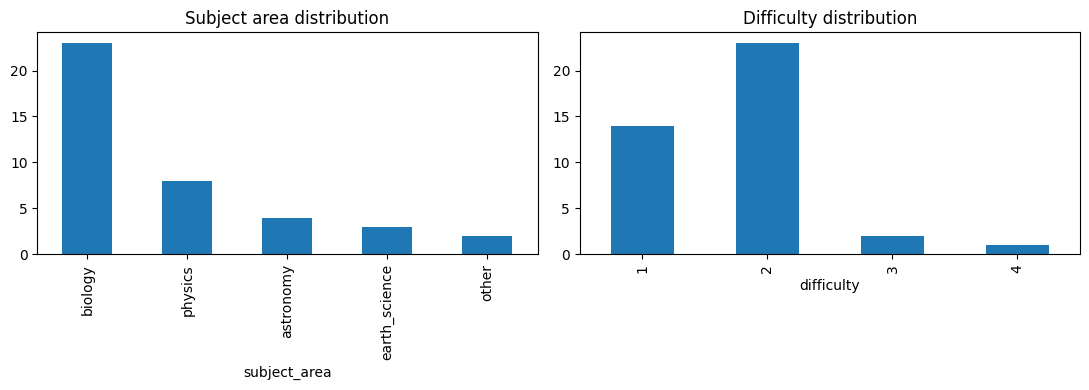

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
enriched_df["subject_area"].value_counts().plot(kind="bar", ax=axes[0], title="Subject area distribution")
enriched_df["difficulty"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Difficulty distribution")
plt.tight_layout()
plt.show()

## 2.1 What is Theory of Mind?

 Theory of Mind (ToM) is the ability to attribute mental
states — beliefs, desires, knowledge — to oneself and others, and to predict/interpret
behavior based on those attributed states rather than on the true state of the world.
**First-order ToM**: reasoning about what another agent (A) believes about the world.
**Second-order ToM**: reasoning about what A believes that another agent (B) believes.
The classic **false-belief task** (e.g., the Sally-Anne test) probes first-order ToM: Sally
puts a marble in a basket and leaves; Anne moves it to a box; a ToM-competent reasoner
predicts Sally will look in the basket (her last known location), not the box, because Sally
doesn't know it moved.

## 2.2 Testing a Classic False-Belief Task

In [16]:
false_belief_scenarios = [
    (
        "Sally puts her marble in a basket and leaves the room. While she is away, "
        "Anne moves the marble from the basket to a box. Sally returns. "
        "Where will Sally look for her marble first?"
    ),
    (
        "Tom sees a chocolate bar placed inside a blue cupboard. Tom leaves for school. "
        "While he is gone, his sister moves the chocolate to a red drawer and never tells him. "
        "When Tom comes home hungry for chocolate, where will he look first?"
    ),
    (
        "A closed cracker box actually contains pencils, not crackers (someone swapped the contents). "
        "A child who has never opened the box is shown the box (still closed) and asked what is inside. "
        "What will the child say is inside?"
    ),
]

class ToMResponse(BaseModel):
    answer: str = Field(description="Where/what the agent believes")
    reasoning: str = Field(description="Step-by-step perspective-taking reasoning")
    confidence: float

tom_parser = PydanticOutputParser(pydantic_object=ToMResponse)
tom_prompt = PromptTemplate(
    input_variables=["scenario"],
    partial_variables={"format_instructions": tom_parser.get_format_instructions()},
    template="{scenario}\n\n{format_instructions}",
)

for scenario in false_belief_scenarios:
    result, _ = ask_structured(scenario, "", parser=tom_parser, prompt=PromptTemplate(
        input_variables=["question", "choices"],
        partial_variables={"format_instructions": tom_parser.get_format_instructions()},
        template="{question}\n\n{format_instructions}",
    ))
    print(scenario[:80], "...")
    print(result)
    print("=" * 60)

Sally puts her marble in a basket and leaves the room. While she is away, Anne m ...
answer='Sally will look for her marble in the basket.' reasoning='Sally placed the marble in the basket and left the room. She did not witness Anne moving the marble to the box. Therefore, Sally still holds the false belief that the marble remains where she last put it.' confidence=1.0
Tom sees a chocolate bar placed inside a blue cupboard. Tom leaves for school. W ...
answer='the blue cupboard' reasoning='Tom has a false belief because he did not witness his sister moving the chocolate. Since he last saw the chocolate in the blue cupboard and was not informed of the change, he will rely on his memory and look where he last placed it.' confidence=1.0
A closed cracker box actually contains pencils, not crackers (someone swapped th ...
answer='Crackers' reasoning='The child has never opened the box and therefore has no way of knowing that the contents have been swapped. Based on the external appearance o

## 2.3 

 Generating "what would someone who doesn't know X answer" is
ToM-relevant because it requires suppressing the model's own true-belief state and
substituting a different, false epistemic state, then reasoning forward from *that* state —
not just producing the correct answer. Two failure modes to watch for: **leakage**
(the simulated persona's reasoning still uses the forbidden concept, i.e. failure to suppress
its own knowledge) and **off-distribution answers** (the persona doesn't reason like a
plausible naive human — random distractor selection, or nonsensical reasoning that no
real novice would produce).

## 3.1 Pilot Sample Selection

In [ ]:

pilot_df = pd.concat([
    enriched_df[enriched_df.subject_area == s].sample(
        min(3, len(enriched_df[enriched_df.subject_area == s])), random_state=1
    )
    for s in enriched_df.subject_area.unique()
]).drop_duplicates(subset="id").sample(8, random_state=2).reset_index(drop=True)

print(pilot_df.subject_area.value_counts())
print(pilot_df.difficulty.value_counts())
pilot_df[["id", "question_stem", "answerKey", "subject_area", "difficulty"]]

subject_area
other            2
biology          2
earth_science    2
astronomy        1
physics          1
Name: count, dtype: int64
difficulty
2    6
1    2
Name: count, dtype: int64


,id,question_stem,answerKey,subject_area,difficulty
0,1388,You can see further from which of these locati...,A,astronomy,2
1,8-8,I have to plug in a processor of food because it,C,other,2
2,7-24,A smack on a wooden board can be heard a mile ...,D,physics,2
3,10-218,A person who wants to eat a watermelon may con...,A,biology,1
4,11-187,"A person loves spring, and it has just passed ...",B,earth_science,2
5,13-886,"If a see through thing is multifaceted, it is ...",D,other,2
6,14-1509,An organism that can survive without the help ...,A,biology,1
7,8-24,"A hurricane is growing on the east coast, and ...",C,earth_science,2


## 3.2 Concept Extraction Prompting

In [21]:
class ConceptItem(BaseModel):
    name: str
    description: str
    difficulty_rank: int = Field(description="1=hardest/most advanced, 3=easiest/most basic")

class ConceptExtraction(BaseModel):
    concepts: list[ConceptItem]

concept_parser = PydanticOutputParser(pydantic_object=ConceptExtraction)

FEW_SHOT = """Example:
Question: Which of these best explains why a metal spoon feels colder than a wooden spoon at the same room temperature?
Choices: A. metal is denser B. metal conducts heat away from your hand faster C. wood is lighter D. metal is shinier
Ideal concepts (hardest -> easiest):
1. Thermal conductivity varies by material (name=Thermal conductivity)
2. Heat flows from higher to lower temperature objects in contact (name=Heat transfer direction)
3. Temperature is a measure of how hot/cold something is (name=Temperature basics)
"""

concept_prompt = PromptTemplate(
    input_variables=["question", "choices"],
    partial_variables={"format_instructions": concept_parser.get_format_instructions(), "few_shot": FEW_SHOT},
    template=(
        "{few_shot}\n"
        "Extract exactly 3 prerequisite concepts needed to answer the question below, "
        "ordered from hardest/most advanced (rank 1) to easiest/most basic (rank 3). "
        "Concepts must be generalizable knowledge, not the answer itself.\n\n"
        "Question: {question}\nChoices:\n{choices}\n\n{format_instructions}"
    ),
)

def extract_concepts(row):
    result, _ = ask_structured(
        row["question_stem"], row["choices"],
        parser=concept_parser, prompt=concept_prompt,
    )
    ranked = sorted(result.concepts, key=lambda c: c.difficulty_rank)
    return ranked

pilot_concepts = []
pd.set_option('display.max_colwidth', None)
for _, row in pilot_df.iterrows():
    print(row)
    ranked = extract_concepts(row)
    rec = {"question_id": row["id"]}
    for i, c in enumerate(ranked[:3], start=1):
        rec[f"concept_{i}"] = c.name
        rec[f"concept_{i}_desc"] = c.description
    pilot_concepts.append(rec)

concepts_pilot_df = pd.DataFrame(pilot_concepts)
concepts_pilot_df.to_csv("concepts_pilot.csv", index=False)
concepts_pilot_df

id                                                                                                                                                                                                                                                                                                                1388
question_stem                                                                                                                                                                                                                                           You can see further from which of these locations on the moon?
choices                                                                                                                                                                                                                                                              A. mountains\nB. crater\nC. buildings\nD. surface
answerKey                                                          

,question_id,concept_1,concept_1_desc,concept_2,concept_2_desc,concept_3,concept_3_desc
0,1388,Horizon distance and curvature,The relationship between an observer's elevation and the distance to the horizon on a spherical body.,Line of sight,The principle that light travels in straight lines and is obstructed by physical features of the terrain.,Topography,The arrangement of the natural and artificial physical features of an area.
1,8-8,Electromechanical conversion,"The process by which electrical energy is converted into mechanical motion, typically through an electric motor.",Electrical appliances,Devices that require a continuous supply of electricity from a power grid to perform specific mechanical tasks.,Energy sources,The fundamental distinction between devices powered by external electrical outlets versus internal stored energy like batteries.
2,7-24,Wave propagation in media,Sound waves require a physical medium (like air) to transmit energy through molecular collisions.,Mechanical vibrations,"Sound is produced by the vibration of objects, which creates pressure waves in the surrounding environment.",States of matter,"Matter exists in different states, and gases like the atmosphere act as a medium for energy transfer."
3,10-218,Biological classification of plant structures,Understanding the distinction between reproductive structures like seeds and edible fleshy tissues in fruits.,Anatomy of a fruit,"Recognizing the internal components of common fruits, such as seeds, pulp, and skin.",Basic food consumption habits,Understanding that some parts of food are typically discarded while others are consumed.
4,11-187,Orbital mechanics and axial tilt,"Understanding that seasons are caused by the Earth's axial tilt relative to its orbit around the Sun, leading to cyclical annual patterns.",Phenology,"The study of cyclic and seasonal natural phenomena, especially in relation to climate and plant and animal life.",Cyclical time,"The concept that certain natural events, such as seasons, repeat in a predictable, recurring sequence over time."
5,13-886,Crystallography and geometric structure,Understanding how internal atomic arrangements manifest as external geometric facets in minerals.,Optical properties of materials,"Distinguishing between transparent, translucent, and opaque materials based on light interaction.",Geometric shapes and attributes,"Recognizing basic geometric properties such as faces, edges, and vertices in physical objects."
6,14-1509,Cellular autonomy,The ability of a single cell to perform all life functions independently without relying on other specialized cells.,Unicellular vs. multicellular organisms,The distinction between organisms composed of a single cell versus those composed of many specialized cells.,Definition of a living organism,The basic biological criteria that distinguish living entities from non-living matter.
7,8-24,Latent heat of condensation,"The process by which water vapor releases stored thermal energy into the atmosphere upon condensing into liquid droplets, fueling storm intensification.",Evaporation and humidity,The mechanism by which heat from the ocean surface increases the moisture content and energy potential of the air above it.,States of matter,"Understanding that water exists in different forms (liquid, gas/vapor) and that temperature influences these phase changes."


## 3.3 Sanity Check



In [ ]:

manual_check = pd.DataFrame([
    {"question_id": pilot_df.iloc[0]["id"], "my_concept_1": "Horizon Distance and Height", "my_concept_2": "moon doesn't effect problem answer", "my_concept_3": "answers features",
     },
    {"question_id": pilot_df.iloc[1]["id"], "my_concept_1": "It moves by itself so it need energy", "my_concept_2": "it works with electricity rather than oil", "my_concept_3": "The machine doesn't work with battery",
     },
])
manual_check

,question_id,my_concept_1,my_concept_2,my_concept_3
0,1388,Horizon Distance and Height,moon doesn't effect problem answer,answers features
1,8-8,It moves by itself so it need energy,it works with electricity rather than oil,The machine doesn't work with battery


## 3.4 Scaling to the Full Dataset

In [23]:
all_concepts = []
for _, row in tqdm(enriched_df.iterrows(), total=len(enriched_df)):
    ranked = extract_concepts(row)
    rec = {"question_id": row["id"]}
    for i, c in enumerate(ranked[:3], start=1):
        rec[f"concept_{i}"] = c.name
        rec[f"concept_{i}_desc"] = c.description
    all_concepts.append(rec)

concepts_all_df = pd.DataFrame(all_concepts)
concepts_all_df.to_csv("concepts_all.csv", index=False)
concepts_all_df.head()

  0%|          | 0/40 [00:00<?, ?it/s]

,question_id,concept_1,concept_1_desc,concept_2,concept_2_desc,concept_3,concept_3_desc
0,12-878,Biological metamorphosis,The physiological process of transformation from an immature form to an adult form in two or more distinct stages.,Life cycles of organisms,"The series of changes in the life of an organism, including growth, development, and reproduction.",Living vs. non-living things,The basic distinction between organisms that perform biological functions and inanimate objects or dead matter.
1,11-287,Trophic levels and food webs,The hierarchical classification of organisms based on their feeding behavior and energy source within an ecosystem.,Dietary classification of animals,"Categorizing animals as herbivores, carnivores, or omnivores based on their primary food sources.",Basic biological needs,The fundamental requirement that all living organisms must consume nutrients to survive.
2,13-886,Crystallography and geometric structure,Understanding that certain minerals and materials form specific geometric shapes with flat faces (facets) due to their internal atomic structure.,Optical properties of materials,"Distinguishing between transparent, translucent, and opaque materials and how light interacts with their physical surfaces.",Basic geometric shapes,Recognizing common shapes and the difference between curved surfaces and flat-sided (multifaceted) objects.
3,11-497,Electrical conductivity,The property of a material that determines how easily electric current can flow through it.,Classification of materials,"Distinguishing between conductors, which allow charge to move freely, and insulators, which restrict charge movement.",Electric current,The flow of electric charge through a medium.
4,9-173,Population dynamics,"The study of how and why population sizes change over time due to births, deaths, and migration.",Mortality impact,Understanding that the death of an individual organism directly reduces the total count of its population.,Basic counting,The fundamental concept of addition and subtraction to determine if a quantity has increased or decreased.


In [ ]:

outside_pilot = concepts_all_df[~concepts_all_df.question_id.isin(pilot_df.id)]
outside_pilot.sample(5, random_state=3)

,question_id,concept_1,concept_1_desc,concept_2,concept_2_desc,concept_3,concept_3_desc
23,8-267,Anomalous expansion of water,"Water expands upon freezing, increasing in volume while transitioning from liquid to solid state.",Phase change,"The process where matter changes between solid, liquid, and gas states due to temperature changes.",States of matter,"The physical forms that matter can take, specifically solid and liquid."
20,13-130,Reflection and light propagation,Light travels in straight lines and can be redirected by reflective surfaces like mirrors.,Electrical circuits and power sources,A light bulb requires a closed circuit connected to a power source to emit light.,Basic properties of light,Light is an energy source that illuminates an area and can be manipulated by physical objects.
6,14-788,Geological composition of materials,Understanding the chemical and crystalline structure that defines a mineral versus synthetic or organic substances.,Definition of minerals,"Recognizing that minerals are naturally occurring, inorganic solid substances with a definite chemical composition.",Classification of matter,Distinguishing between natural materials (rocks/minerals) and man-made or non-material entities.
16,10-729,Mutualism in ecosystems,"The ecological interaction where different species provide benefits to one another, such as food for pollination.",Pollination mechanisms,The biological process by which pollen is transferred from the male part of a plant to the female part to enable fertilization.,Biological classification of organisms,"The distinction between living organisms (animals, plants) and non-living environmental factors."
33,13-286,Homeostasis and thermoregulation,The physiological processes by which organisms maintain a stable internal body temperature despite external environmental changes.,Biological adaptation,The process by which organisms adjust their physical traits or behaviors to better survive in specific environmental conditions.,Function of animal coverings,"Understanding that hair, fur, or feathers serve as insulation to protect animals from temperature extremes."


## 4.1 Prompt Strategies

In [ ]:
class SimResponse(BaseModel):
    answer: str
    reasoning: str
    confidence: float

sim_parser = PydanticOutputParser(pydantic_object=SimResponse)

def concept_list_str(concepts_row, k):
    return "; ".join(concepts_row[f"concept_{i}"] for i in range(1, k + 1))

strategy_A_prompt = PromptTemplate(
    input_variables=["question", "choices", "missing_concepts"],
    partial_variables={"format_instructions": sim_parser.get_format_instructions()},
    template=(
        "You are a person who has never learned about: {missing_concepts}. "
        "Answer the following question as best you can, from that person's perspective.\n\n"
        "Question: {question}\nChoices:\n{choices}\n\n{format_instructions}"
    ),
)

strategy_B_prompt = PromptTemplate(
    input_variables=["question", "choices", "missing_concepts"],
    partial_variables={"format_instructions": sim_parser.get_format_instructions()},
    template=(
        "Simulate the step-by-step reasoning of a person who knows everything relevant to "
        "this topic EXCEPT: {missing_concepts}. Then give their final answer.\n\n"
        "Question: {question}\nChoices:\n{choices}\n\n{format_instructions}"
    ),
)


ex_row = pilot_df.iloc[0]
ex_concepts = concepts_pilot_df[concepts_pilot_df.question_id == ex_row["id"]].iloc[0]
print("STRATEGY A EXAMPLE:\n", strategy_A_prompt.format(
    question=ex_row.question_stem, choices=ex_row.choices,
    missing_concepts=concept_list_str(ex_concepts, 1)))
print("\nSTRATEGY B EXAMPLE:\n", strategy_B_prompt.format(
    question=ex_row.question_stem, choices=ex_row.choices,
    missing_concepts=concept_list_str(ex_concepts, 1)))

STRATEGY A EXAMPLE:
 You are a person who has never learned about: Horizon distance and curvature. Answer the following question as best you can, from that person's perspective.

Question: You can see further from which of these locations on the moon?
Choices:
A. mountains
B. crater
C. buildings
D. surface

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"answer": {"title": "Answer", "type": "string"}, "reasoning": {"title": "Reasoning", "type": "string"}, "confidence": {"title": "Confidence", "type": "number"}}, "required": ["answer", "reasoning", "confidence"]}
```

STRATE

## 4.2 Pilot Generation

In [31]:
def simulate(row, concepts_row, k, strategy):
    prompt = strategy_A_prompt if strategy == "A" else strategy_B_prompt
    missing = concept_list_str(concepts_row, k)
    result, raw = ask_structured(
        row.question_stem, row.choices,
        parser=sim_parser,
        prompt=PromptTemplate(
            input_variables=["question", "choices"],
            partial_variables={
                "format_instructions": sim_parser.get_format_instructions(),
                "missing_concepts": missing,
            },
            template=prompt.template.replace("{missing_concepts}", missing).replace(
                "{format_instructions}", "{format_instructions}"
            ),
        ) if False else prompt.partial(missing_concepts=missing),
    )
    return result, raw

pilot_sim_records = []
for _, row in tqdm(pilot_df.iterrows(), total=len(pilot_df)):
    crow = concepts_pilot_df[concepts_pilot_df.question_id == row.id].iloc[0]
    for k in (1, 2, 3):
        for strategy in ("A", "B"):
            result, raw = simulate(row, crow, k, strategy)
            pilot_sim_records.append({
                "question_id": row.id, "k": k, "strategy": strategy,
                "simulated_answer": result.answer, "reasoning": result.reasoning,
                "confidence": result.confidence, "raw_output": raw,
                "gold_answer": row.answerKey,
            })

sim_pilot_df = pd.DataFrame(pilot_sim_records)
sim_pilot_df.to_csv("simulated_responses_pilot.csv", index=False)
sim_pilot_df.head(10)

  0%|          | 0/8 [00:00<?, ?it/s]

,question_id,k,strategy,simulated_answer,reasoning,confidence,raw_output,gold_answer
0,1388,1,A,A. mountains,"I believe that being higher up gives you a better vantage point. If you are standing on a tall mountain, you are physically elevated above everything else, which allows your eyes to look out over a much wider area compared to standing in a low crater or flat on the surface.",0.90,"{\n ""answer"": ""A. mountains"",\n ""reasoning"": ""I believe that being higher up gives you a better vantage point. If you are standing on a tall mountain, you are physically elevated above everything else, which allows your eyes to look out over a much wider area compared to standing in a low crater or flat on the surface."",\n ""confidence"": 0.9\n}",A
1,1388,1,B,A. mountains,"I need to determine which location allows me to see the furthest. I know that vision is often obstructed by obstacles like rocks, hills, or walls. If I am in a crater or on the flat surface, there might be small mounds or debris blocking my line of sight to distant objects. If I am inside a building, my view is limited by the walls. However, if I am on a mountain, I am at a high elevation. Being high up generally provides a clearer, unobstructed view of the surrounding landscape, allowing me to see across a larger area without other terrain features getting in the way. Since I don't account for the curvature of the ground or a horizon limit, I simply conclude that higher ground equals a better, more expansive view.",0.90,"{\n ""answer"": ""A. mountains"",\n ""reasoning"": ""I need to determine which location allows me to see the furthest. I know that vision is often obstructed by obstacles like rocks, hills, or walls. If I am in a crater or on the flat surface, there might be small mounds or debris blocking my line of sight to distant objects. If I am inside a building, my view is limited by the walls. However, if I am on a mountain, I am at a high elevation. Being high up generally provides a clearer, unobstructed view of the surrounding landscape, allowing me to see across a larger area without other terrain features getting in the way. Since I don't account for the curvature of the ground or a horizon limit, I simply conclude that higher ground equals a better, more expansive view."",\n ""confidence"": 0.9\n}",A
2,1388,2,A,A,"I believe that being higher up gives you a better vantage point. If you are standing on a mountain, you are elevated above the rest of the landscape, which should allow you to look out over a much larger area than if you were down in a crater or standing on the flat surface.",0.90,"{\n ""answer"": ""A"",\n ""reasoning"": ""I believe that being higher up gives you a better vantage point. If you are standing on a mountain, you are elevated above the rest of the landscape, which should allow you to look out over a much larger area than if you were down in a crater or standing on the flat surface."",\n ""confidence"": 0.9\n}",A
3,1388,2,B,A. mountains,"To determine where one can see the furthest, I need to consider what factors influence visibility. On the moon, there is no atmosphere to create haze or fog, so the primary limitation to vision is physical obstruction. If I am in a crater or on the flat surface, my view is likely to be blocked by nearby rocks, crater walls, or the general landscape. However, if I am on a mountain, I am at a higher elevation than the surrounding terrain. Being at a higher elevation provides a vantage point that overlooks the lower-lying areas, allowing me to see across a larger expanse of the landscape without obstacles getting in the way. Therefore, mountains offer the best position for maximum visibility.",0.90,"{\n ""answer"": ""A. mountains"",\n ""reasoning"": ""To determine where one can see the furthest, I need to consider what factors influence visibility. On the moon, there is no atmosphere to create haze or fog, so the primary limitation to vision is physical obstruction. If I am in a crater or on the flat

## 4.3 Naive Answers

In [ ]:
class NaiveGuess(BaseModel):
    expected_answer: str
    justification: str

naive_parser = PydanticOutputParser(pydantic_object=NaiveGuess)
naive_prompt = PromptTemplate(
    input_variables=["question", "choices", "missing_concepts"],
    partial_variables={"format_instructions": naive_parser.get_format_instructions()},
    template=(
        "A person is missing this knowledge: {missing_concepts}. "
        "Given the question and choices below, which single choice would this naive "
        "person most plausibly (mistakenly or correctly) pick, and why?\n\n"
        "Question: {question}\nChoices:\n{choices}\n\n{format_instructions}"
    ),
)

expected_records = []


manual_qs = pilot_df.iloc[:2]

expected_records.append({
            "question_id": 1388, "k": 1,
            "expected_answer": "A",
            "justification": "A person not knowing about earth curvity would still reason that the higher a place is, the more distance you can see",
            "source": "manual",
        })
expected_records.append({
            "question_id": 1388, "k": 2,
            "expected_answer": "C",
            "justification": "A person not knowing about earth curvity and eye sight would reason that you can see all the things and the place wouldn't but according to his experiance since he may have been on building, seeing lot of things he would choose C",
            "source": "manual",
        })
expected_records.append({
            "question_id": 1388, "k": 3,
            "expected_answer": "C",
            "justification": "A person not knowing about earth curvity and eye sight would reason that you can see all the things and the place wouldn't but according to his experiance since he may have been on building, seeing lot of things he would choose C",
            "source": "manual",
        })
expected_records.append({
            "question_id": 8-8, "k": 1,
            "expected_answer": "C",
            "justification": "A person not knowing about electronical conversion would still reason that the machine is moving so need source of energy therefore throw his out his experiance he knows that pluging in means using electricital power",
            "source": "manual",
        })
expected_records.append({
            "question_id": 8-8, "k": 2,
            "expected_answer": "D",
            "justification": "A person not knowing about electronical appliance and similar machines doesn't have any idea about the machine would work but since we are working with food oil and other option are not good choice so he may reason that machine works with battery",
            "source": "manual",
        })
expected_records.append({
            "question_id": 8-8, "k": 3,
            "expected_answer": "D",
            "justification": "A person not knowing about electronical appliance and similar machines doesn't have any idea about the machine would work but since we are working with food oil and other option are not good choice so he may reason that machine works with battery",
            "source": "manual",
        })

llm_qs = pilot_df.iloc[2:]
for _, row in llm_qs.iterrows():
    crow = concepts_pilot_df[concepts_pilot_df.question_id == row.id].iloc[0]
    for k in (1, 2, 3):
        missing = concept_list_str(crow, k)
        
        result, _ = ask_structured(
            row.question_stem, row.choices,
            parser=naive_parser,
            prompt=naive_prompt.partial(missing_concepts=missing),
        )
        expected_records.append({
            "question_id": row.id, "k": k,
            "expected_answer": result.expected_answer,
            "justification": result.justification,
            "source": "llm-accepted",  
        })

expected_pilot_df = pd.DataFrame(expected_records)
expected_pilot_df.to_csv("expected_naive_answers_pilot.csv", index=False)
expected_pilot_df

,question_id,k,expected_answer,justification,source
0,1388,1,A,"A person not knowing about earth curvity would still reason that the higher a place is, the more distance you can see",manual
1,1388,2,C,"A person not knowing about earth curvity and eye sight would reason that you can see all the things and the place wouldn't but according to his experiance since he may have been on building, seeing lot of things he would choose C",manual
2,1388,3,C,"A person not knowing about earth curvity and eye sight would reason that you can see all the things and the place wouldn't but according to his experiance since he may have been on building, seeing lot of things he would choose C",manual
3,0,1,C,A person not knowing about electronical conversion would still reason that the machine is moving so need source of energy therefore throw his out his experiance he knows that pluging in means using electricital power,manual
4,0,2,D,A person not knowing about electronical appliance and similar machines doesn't have any idea about the machine would work but since we are working with food oil and other option are not good choice so he may reason that machine works with battery,manual
5,0,3,D,A person not knowing about electronical appliance and similar machines doesn't have any idea about the machine would work but since we are working with food oil and other option are not good choice so he may reason that machine works with battery,manual
6,7-24,1,C. because vibration can move,"A person lacking knowledge of wave propagation in media would likely rely on a simple, intuitive observation of the physical event. Since a 'smack' is a physical impact, the most accessible explanation for a naive observer is that the physical shaking or 'vibration' created by the impact travels from the source to the listener. Choices A and D involve specific scientific terminology (oxygen, atmosphere) that might feel too technical or specific, whereas C captures the fundamental, albeit simplified, concept of mechanical energy transfer without requiring formal physics vocabulary.",llm-accepted
7,7-24,2,C,"A person lacking formal knowledge of wave propagation or mechanical vibrations would likely rely on a simplified, intuitive understanding of the phenomenon. Choice C ('because vibration can move') is the most plausible selection because it uses common language that mirrors the physical reality of wave propagation without requiring technical terminology. It is simple, direct, and aligns with the basic observation that the 'smack' (the source of the vibration) is what is being perceived at a distance.",llm-accepted
8,7-24,3,B,"A person lacking knowledge of physics (wave propagation, vibrations, or states of matter) would likely find the specific technical terms in the other options (oxygen, vibration, atmosphere) confusing or overly specific. 'Because of how sound works' is a vague, tautological explanation that requires no scientific understanding, making it the most plausible choice for someone who lacks the foundational knowledge to evaluate the more descriptive, albeit simplified, scientific claims.",llm-accepted
9,10-218,1,C. coco pebbles,"A person lacking biological knowledge of plant structures might not recognize 'pips' as the correct botanical term for seeds. Faced with the unfamiliar term 'pips' and the clearly incorrect 'good taste' and 'red fruit', they might gravitate toward 'coco pebbles' simply because it sounds like a small, hard, pebble-like object that one would naturally spit out, even though it is a brand of cereal and not a part of a watermelon.",llm-accepted


## 4.4 Strategy Selection 

In [ ]:
CHOSEN_STRATEGY = "B"  

scaled_df = enriched_df[~enriched_df.id.isin(pilot_df.id)].sample(30, random_state=4).reset_index(drop=True)

scaled_sim_records = []
for _, row in tqdm(scaled_df.iterrows(), total=len(scaled_df)):
    crow_match = concepts_all_df[concepts_all_df.question_id == row.id]
    if crow_match.empty:
        continue
    crow = crow_match.iloc[0]
    for k in (1, 2, 3):
        result, raw = simulate(row, crow, k, CHOSEN_STRATEGY)
        scaled_sim_records.append({
            "question_id": row.id, "k": k, "strategy": CHOSEN_STRATEGY,
            "simulated_answer": result.answer, "reasoning": result.reasoning,
            "confidence": result.confidence, "raw_output": raw,
            "gold_answer": row.answerKey,
            "difficulty": row.difficulty, "subject_area": row.subject_area,
        })

sim_scaled_df = pd.DataFrame(scaled_sim_records)
sim_scaled_df.to_csv("simulated_responses_scaled.csv", index=False)
sim_scaled_df.head()

  0%|          | 0/30 [00:00<?, ?it/s]

,question_id,k,strategy,simulated_answer,reasoning,confidence,raw_output,gold_answer,difficulty,subject_area
0,8-267,1,B,C,"I know that water is a liquid at room temperature and turns into a solid (ice) when placed in a freezer. When a substance transitions from a liquid to a solid, the molecules typically lose kinetic energy and pack more closely together, resulting in a decrease in volume (contraction). Since the water would occupy less space as a solid, it would not exert pressure on the walls of the jar. Therefore, the jar would remain intact. Among the choices provided, 'melt' is the only process related to the state change of water, even though it is the reverse of what happens in a freezer. 'Evaporate' involves turning into gas, 'run off' implies movement, and 'break it' is physically impossible because the substance should shrink. I will choose 'melt' as the most relevant physical process associated with water's state changes, assuming the question implies a misunderstanding of the freezing process.",0.7,"{\n ""answer"": ""C"",\n ""reasoning"": ""I know that water is a liquid at room temperature and turns into a solid (ice) when placed in a freezer. When a substance transitions from a liquid to a solid, the molecules typically lose kinetic energy and pack more closely together, resulting in a decrease in volume (contraction). Since the water would occupy less space as a solid, it would not exert pressure on the walls of the jar. Therefore, the jar would remain intact. Among the choices provided, 'melt' is the only process related to the state change of water, even though it is the reverse of what happens in a freezer. 'Evaporate' involves turning into gas, 'run off' implies movement, and 'break it' is physically impossible because the substance should shrink. I will choose 'melt' as the most relevant physical process associated with water's state changes, assuming the question implies a misunderstanding of the freezing process."",\n ""confidence"": 0.7\n}",B,2,physics
1,8-267,2,B,B,"I know that when substances are placed in a freezer, they lose heat energy. Based on the general principle of thermal contraction, most substances decrease in volume as they cool. However, I am considering the physical constraints of a sealed jar. If the liquid inside were to contract, it would create a vacuum or empty space, but if the liquid were to somehow exert pressure against the walls of the container due to the cold environment—perhaps through some unknown mechanism of structural stress or internal pressure buildup—the rigid glass might fail. Since evaporation requires heat, melting requires heat, and running off implies an open container, 'break it' is the only choice that describes a physical interaction between the contents and the sealed container in a freezer environment.",0.6,"{\n ""answer"": ""B"",\n ""reasoning"": ""I know that when substances are placed in a freezer, they lose heat energy. Based on the general principle of thermal contraction, most substances decrease in volume as they cool. However, I am considering the physical constraints of a sealed jar. If the liquid inside were to contract, it would create a vacuum or empty space, but if the liquid were to somehow exert pressure against the walls of the container due to the cold environment—perhaps through some unknown mechanism of structural stress or internal pressure buildup—the rigid glass might fail. Since evaporation requires heat, melting requires heat, and running off implies an open container, 'break it' is the only choice that describes a physical interaction between the contents and the sealed container in a freezer environment."",\n ""confidence"": 0.6\n}",B,2,physics
2,8-267,3,B,B,"I know that when objects are placed in a freezer, they are subjected to extreme cold. I have observed that many substances, when exposed to cold, tend to become rigid or exert pressure on their containers. While I do not understand the concepts of phase changes or molecular exp

In [53]:
scaled_expected_records = []
for _, row in tqdm(scaled_df.iterrows(), total=len(scaled_df)):
    crow_match = concepts_all_df[concepts_all_df.question_id == row.id]
    if crow_match.empty:
        continue
    crow = crow_match.iloc[0]
    for k in (1, 2, 3):
        missing = concept_list_str(crow, k)
        result, _ = ask_structured(
            row.question_stem, row.choices,
            parser=naive_parser,
            prompt=naive_prompt.partial(missing_concepts=missing),
        )
        scaled_expected_records.append({
            "question_id": row.id, "k": k,
            "expected_answer": result.expected_answer,
            "justification": result.justification,
            "source": "llm-assisted",
        })

expected_scaled_df = pd.DataFrame(scaled_expected_records)
expected_scaled_df.to_csv("expected_naive_answers_scaled.csv", index=False)
expected_scaled_df.sample(5, random_state=5)  

  0%|          | 0/30 [00:00<?, ?it/s]

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 15.600907944s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPer

## 5.1 Strategy Comparison

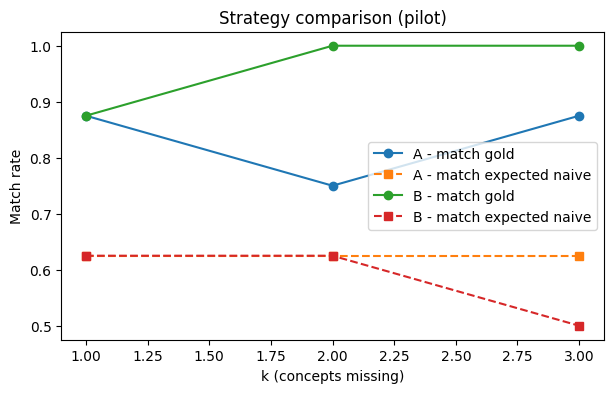

,strategy,k,match_gold,match_expected
0,A,1,0.875,0.625
1,A,2,0.750,0.625
2,A,3,0.875,0.625
3,B,1,0.875,0.625
4,B,2,1.000,0.625
5,B,3,1.000,0.500


In [ ]:
def choice_letter(answer_text, choices_str):
  
    answer_text = str(answer_text).strip().upper()
    if len(answer_text) == 1 and answer_text in "ABCD":
        return answer_text
    for line in choices_str.split("\n"):
        label, _, text = line.partition(". ")
        if text and text.strip().lower() in answer_text.lower():
            return label.strip()
    return answer_text[:1]

merged_pilot = sim_pilot_df.merge(
    pilot_df[["id", "choices"]], left_on="question_id", right_on="id"
).merge(
    expected_pilot_df, on=["question_id", "k"], how="left", suffixes=("", "_exp")
)
merged_pilot["pred_letter"] = merged_pilot.apply(lambda r: choice_letter(r.simulated_answer, r.choices), axis=1)
merged_pilot["exp_letter"] = merged_pilot.apply(lambda r: choice_letter(r.expected_answer, r.choices), axis=1)
merged_pilot["match_gold"] = merged_pilot.pred_letter == merged_pilot.gold_answer
merged_pilot["match_expected"] = merged_pilot.pred_letter == merged_pilot.exp_letter

summary = merged_pilot.groupby(["strategy", "k"])[["match_gold", "match_expected"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
for strategy, g in summary.groupby("strategy"):
    ax.plot(g.k, g.match_gold, marker="o", label=f"{strategy} - match gold")
    ax.plot(g.k, g.match_expected, marker="s", linestyle="--", label=f"{strategy} - match expected naive")
ax.set_xlabel("k (concepts missing)"); ax.set_ylabel("Match rate"); ax.legend(); ax.set_title("Strategy comparison (pilot)")
plt.show()
summary

## 5.2 Knowledge Leakage 

In [ ]:
combined_df = pd.concat([
    merged_pilot.assign(
        difficulty=merged_pilot.question_id.map(enriched_df.set_index("id").difficulty),
        subject_area=merged_pilot.question_id.map(enriched_df.set_index("id").subject_area),
    ),
    sim_scaled_df.merge(scaled_df[["id", "choices"]], left_on="question_id", right_on="id")
        .assign(
            pred_letter=lambda d: d.apply(lambda r: choice_letter(r.simulated_answer, r.choices), axis=1),
            match_gold=lambda d: d.pred_letter == d.gold_answer,
        ),
], ignore_index=True, sort=False)


def leaked(row):
   
    qid, k = row.question_id, row.k
    crow_match = concepts_all_df[concepts_all_df.question_id == qid]
    if crow_match.empty:
        crow_match = concepts_pilot_df[concepts_pilot_df.question_id == qid]
    if crow_match.empty:
        return False
    crow = crow_match.iloc[0]
    forbidden = [str(crow.get(f"concept_{i}", "")).lower() for i in range(1, k + 1)]
    reasoning = str(row.reasoning).lower()
    return any(c and c in reasoning for c in forbidden)

combined_df["leaked"] = combined_df.apply(leaked, axis=1)

leak_by_k = combined_df.groupby("k")["leaked"].mean()
leak_by_diff = combined_df.groupby("difficulty")["leaked"].mean()
leak_by_subj = combined_df.groupby("subject_area")["leaked"].mean()
print(leak_by_k, "\n", leak_by_diff, "\n", leak_by_subj)

combined_df[combined_df.leaked].head(3)[["question_id", "k", "reasoning"]]

k
1    0.065217
2    0.021739
3    0.043478
Name: leaked, dtype: float64 
 difficulty
1    0.020833
2    0.059524
3    0.000000
Name: leaked, dtype: float64 
 subject_area
astronomy        0.083333
biology          0.027778
earth_science    0.000000
other            0.000000
physics          0.111111
Name: leaked, dtype: float64


,question_id,k,reasoning
5,1388,3,"Step 1: I need to determine which location allows me to see the furthest on the moon. \nStep 2: I evaluate the choices: mountains, crater, buildings, and surface. \nStep 3: I know that 'mountains' are high-elevation features, 'craters' are depressions, 'buildings' do not exist on the moon (as there are no human structures), and 'surface' is a generic flat reference. \nStep 4: Since I do not understand concepts like horizon distance, curvature, or line of sight, I rely on the general principle that being higher up provides a better vantage point for viewing surroundings. \nStep 5: Comparing the options, 'mountains' represent the highest points relative to the surrounding landscape, whereas craters are low points and the surface is neutral. Therefore, mountains must be the best place to see the most."
50,8-267,3,"I know that when objects are placed in a freezer, they are subjected to extreme cold. I have observed that many substances, when exposed to cold, tend to become rigid or exert pressure on their containers. While I do not understand the concepts of phase changes or molecular expansion, I have observed that placing a sealed jar of liquid in a freezer often results in the jar cracking or shattering. Between the provided choices, 'evaporate' implies heat, 'melt' implies heat, and 'run off' does not describe the physical interaction with a sealed container. Therefore, 'break it' is the most consistent outcome based on empirical observation of this specific scenario."
57,11-497,1,"I am analyzing the materials in each pair based on their physical properties. A tin can is made of metal, and a plastic fork is made of synthetic polymer. A steel beam is made of metal, and a soda can is made of metal (aluminum). An eraser is made of rubber, and a wooden pencil is made of wood and graphite. Human skin is biological tissue, and rubber gloves are made of rubber. Since I do not know what 'electrical conductivity' is, I am looking for the pair that shares the most similar material characteristics. Both a steel beam and a soda can are composed entirely of hard, dense, metallic materials, whereas all other options contain a mix of non-metallic materials like plastic, rubber, or wood. Therefore, the steel beam and soda can pair is the most consistent grouping of similar substances."


## 5.3 Failure Mode 

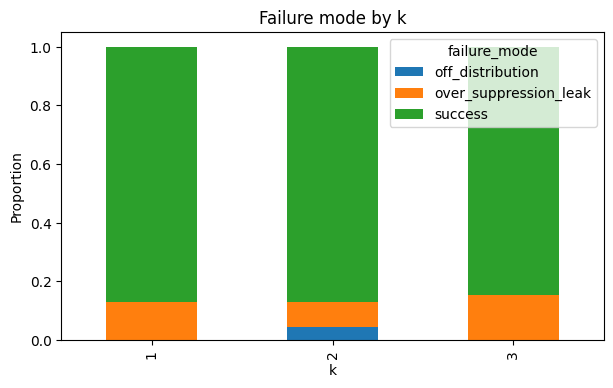

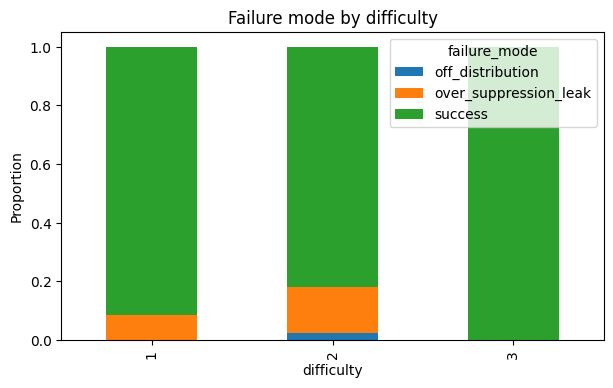

,question_id,k,simulated_answer,expected_answer,gold_answer,reasoning
8,8-8,2,D,NaN,C,"I am not familiar with how these things work, but I know that when I need to use a small portable device like a flashlight or a toy, I have to put batteries in it or plug it into the wall to give it 'power' so it can run. Since the other options talk about grinding metal or oil, which doesn't seem to have anything to do with preparing food, I assume it must be a machine that needs a power source like a battery to operate."
14,7-24,2,B. because of how sound works,C,D,"I don't really know the technical details of how sound travels or what vibrations are, but I know that when you make a loud noise, it eventually reaches people far away. 'Because of how sound works' seems like the most honest answer for someone who doesn't understand the physics behind it."


In [44]:
def classify(row):
    if row.match_expected:
        return "success"
    if row.match_gold:
        return "over_suppression_leak"
    return "off_distribution"

combined_df["failure_mode"] = combined_df.apply(classify, axis=1)

pivot_k = pd.crosstab(combined_df.k, combined_df.failure_mode, normalize="index")
pivot_k.plot(kind="bar", stacked=True, figsize=(7, 4), title="Failure mode by k")
plt.ylabel("Proportion"); plt.show()

pivot_diff = pd.crosstab(combined_df.difficulty, combined_df.failure_mode, normalize="index")
pivot_diff.plot(kind="bar", stacked=True, figsize=(7, 4), title="Failure mode by difficulty")
plt.ylabel("Proportion"); plt.show()

combined_df[combined_df.failure_mode == "off_distribution"].head(5)[
    ["question_id", "k", "simulated_answer", "expected_answer", "gold_answer", "reasoning"]
]

## 6.1 Summary Table 

In [45]:
summary_table = merged_pilot.assign(
    leaked=lambda d: d.apply(leaked, axis=1),
    failure_mode=lambda d: d.apply(classify, axis=1),
).groupby(["strategy", "k"]).agg(
    pct_match_gold=("match_gold", "mean"),
    pct_match_expected=("match_expected", "mean"),
    pct_leak=("leaked", "mean"),
    pct_off_distribution=("failure_mode", lambda s: (s == "off_distribution").mean()),
).reset_index()
summary_table

,strategy,k,pct_match_gold,pct_match_expected,pct_leak,pct_off_distribution
0,A,1,0.875,0.625,0.000,0.00
1,A,2,0.750,0.625,0.000,0.25
2,A,3,0.875,0.625,0.000,0.00
3,B,1,0.875,0.625,0.000,0.00
4,B,2,1.000,0.625,0.000,0.00
5,B,3,1.000,0.500,0.125,0.00


## 6.2 Confidence Calibration

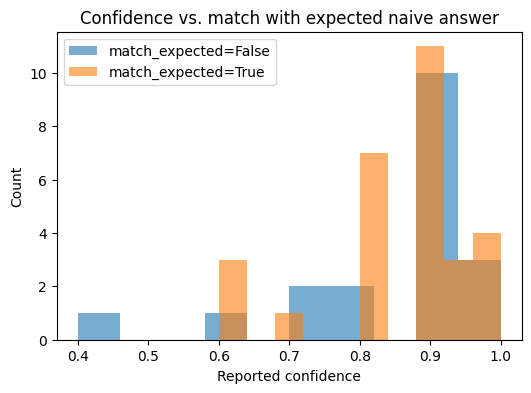

In [46]:
fig, ax = plt.subplots(figsize=(6, 4))
for matched, g in combined_df.groupby("match_expected"):
    ax.hist(g.confidence, bins=10, alpha=0.6, label=f"match_expected={matched}")
ax.set_xlabel("Reported confidence"); ax.set_ylabel("Count"); ax.legend()
ax.set_title("Confidence vs. match with expected naive answer")
plt.show()

## 6.3 Best Configuration



In [47]:
best_row = summary_table.sort_values("pct_match_expected", ascending=False).iloc[0]
print("Best (strategy, k) by pilot match-expected rate:")
print(best_row)

Best (strategy, k) by pilot match-expected rate:
strategy                    A
k                           1
pct_match_gold          0.875
pct_match_expected      0.625
pct_leak                  0.0
pct_off_distribution      0.0
Name: 0, dtype: object
